# Linear Regression

It is the first algorithm that any ML developer will ever learn and conceptually it is the easiest one. But mathematically it is a very difficult problem to solve.

First let's talk about what it does...


# What linear regression actually do?

I draws a line. That's it.

Let's say you have some data like this.

In [29]:
import pandas as pd
import numpy as np

In [30]:
data = pd.DataFrame({
    'feature 1': [1, 2, 3, 4, 5],
    'feature 2': [1.5, 2, 2.5, 3, 3.5],
    'target': [2, 3, 4, 5, 6]
    }
)
data

,feature 1,feature 2,target
0,1,1.5,2
1,2,2.0,3
2,3,2.5,4
3,4,3.0,5
4,5,3.5,6


We have two features and one target.

Now, let's try see what `feature 1` vs `target` and `feature 2` vs `target` looks like.

<Axes: xlabel='feature 1'>

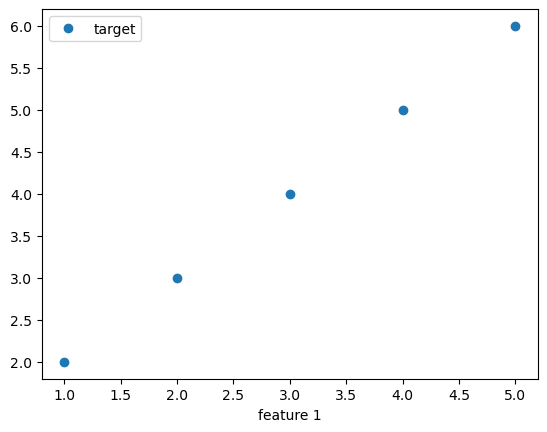

In [31]:
data.plot(x='feature 1', y='target', style='o')

<Axes: xlabel='feature 2'>

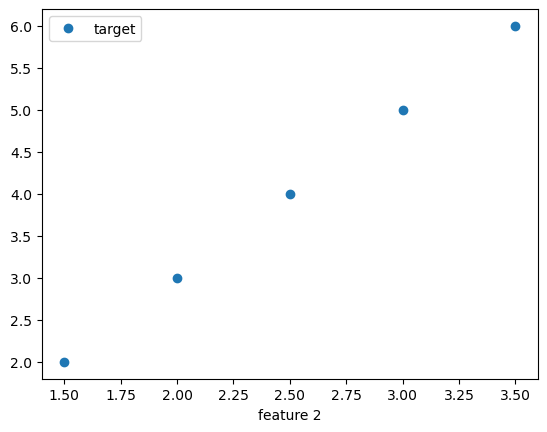

In [32]:
data.plot(x='feature 2', y='target', style='o')

Both looks identicle but if you look closer `feature 2` has values difference is only `0.5` but `feature 1` has values difference of `1`. 

Now you just have to ignore what the values are and ask can I draw a line to represent the relationship between `feature 1` and `target` and `feature 2` and `target`?

The answer is `yes`.

But that's easy to see. But what if I put some noise in the data?

In [33]:
np.random.seed(44)
data['feature 1'] += np.random.rand(5)
data['feature 2'] += np.random.rand(5)
data['target'] += np.random.rand(5)

In [34]:
data

,feature 1,feature 2,target
0,1.834842,2.109238,2.960526
1,2.104796,2.393780,3.456621
2,3.744640,2.909073,4.427652
3,4.360501,3.509902,5.113464
4,5.359311,4.210148,6.217899


<Axes: xlabel='feature 1'>

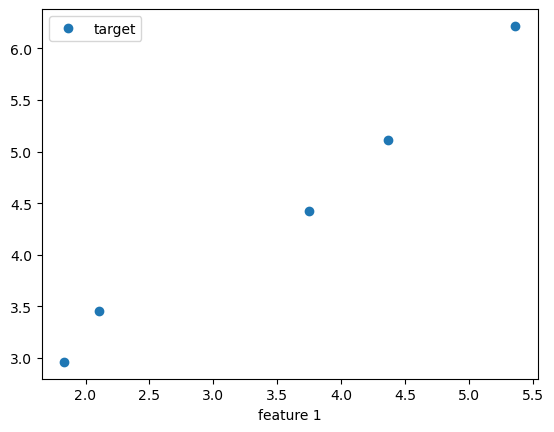

In [35]:
data.plot(x='feature 1', y='target', style='o')

<Axes: xlabel='feature 2'>

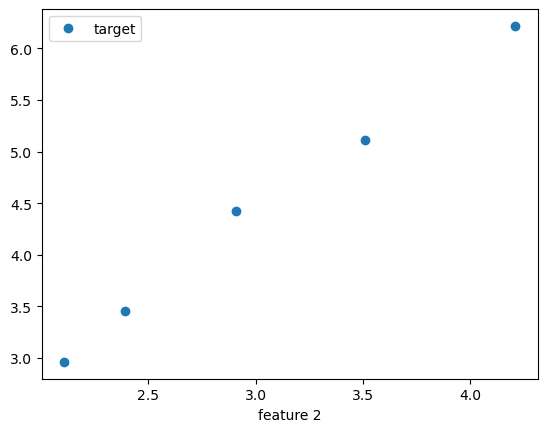

In [36]:
data.plot(x='feature 2', y='target', style='o')

Now, can we draw a line to represent the relationship between `feature 1` and `target` and `feature 2` and `target`?

The answer is still `yes`. The only different is that we have to imagine a line that `best fits` the data.

Now you might ask what does that even mean? `best fits`?

For example, I example let's say I draw line like this.

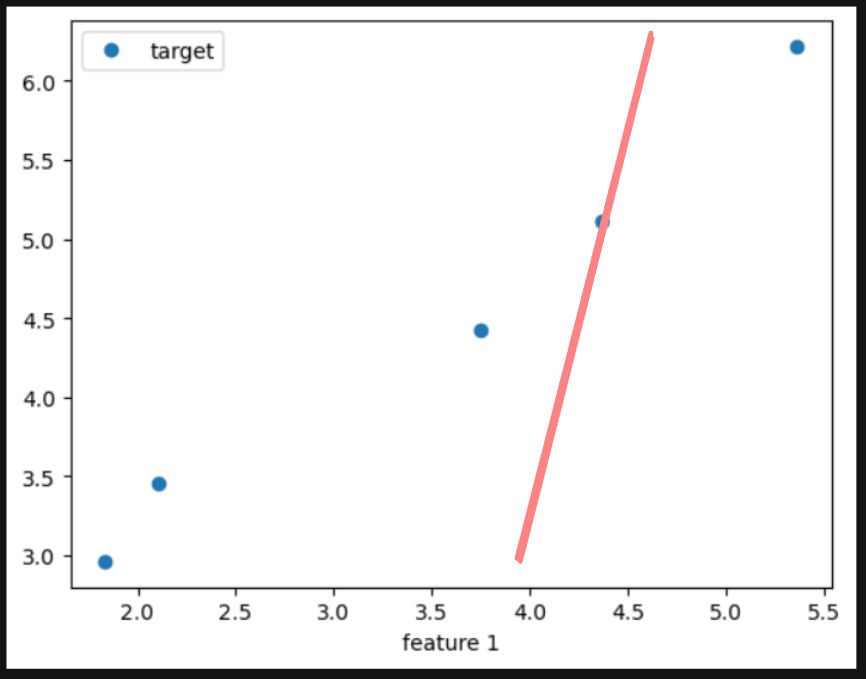

Does this almost perfectly represent the relationship between `feature 1` and `target`?

Clearly no.

What if I draw a line like this?

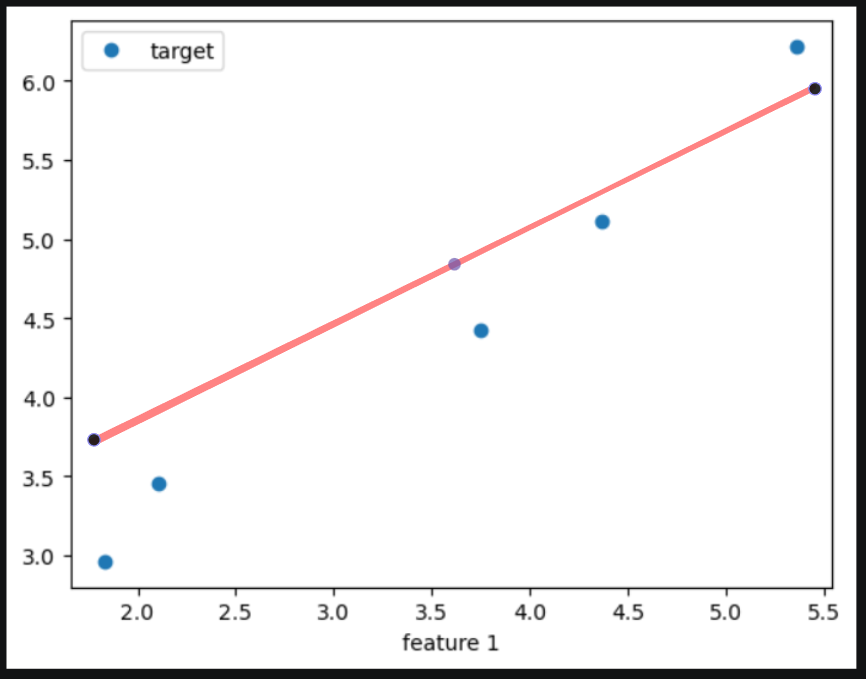

Close close but not quite.

now what about this line.

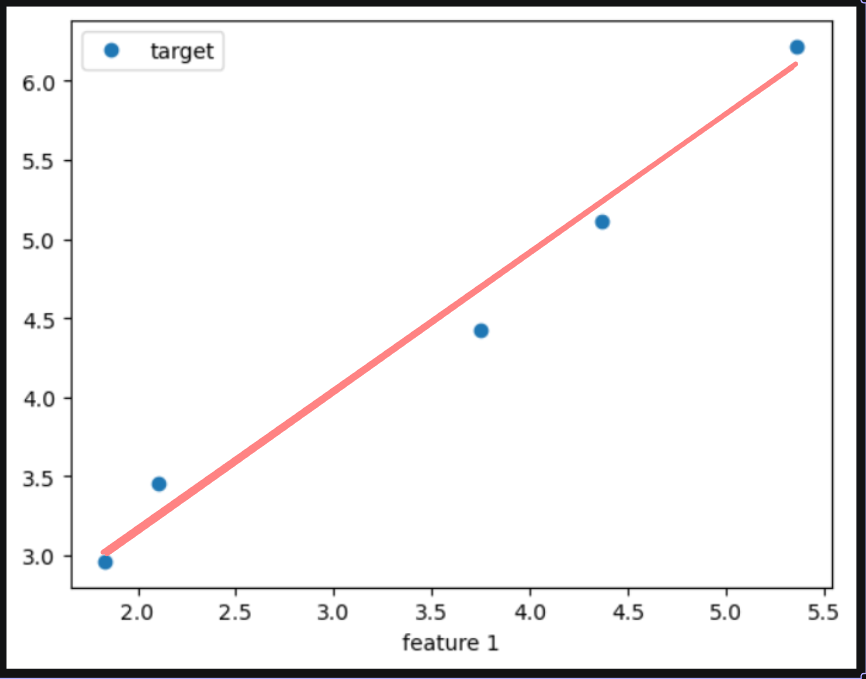

Looks, pretty good, right?

This is what `best fits` means.

We know that a line cannot represent a non-linear relationship perfectly but we can make it as close as possible.

And this is the idea behind the greatest algorithm in all of Machine Learning, `Linear Regression`.

A simple line that will try it's best to represent the relationship between a `feature` and a `target`.

<Axes: xlabel='feature 2', ylabel='target'>

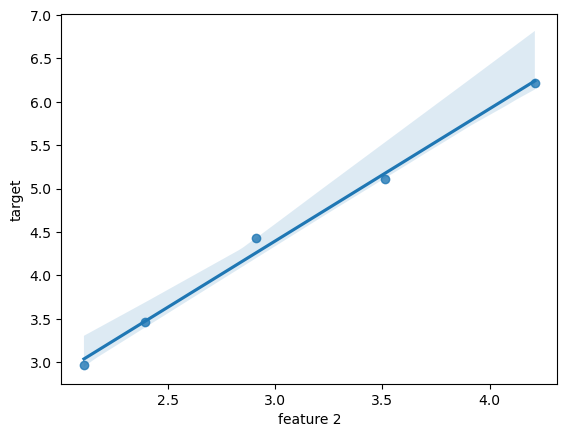

In [39]:
import seaborn as sns

sns.regplot(x='feature 2', y='target', data=data)

# The Math

Now, that you have the concept of linear regression, let's go deeper.

Now, we know that we have to find the line that best fits the data.

## What is the line ?

But we cannot just tell the computer to manually figure it out.

We need a mathematical model.

First let's me ask you a question. What is the mathematical model of a line?

$$
y = mx + c
$$

right?

$
Here,\\
m = slope of the line\\
c = intercept\\
$

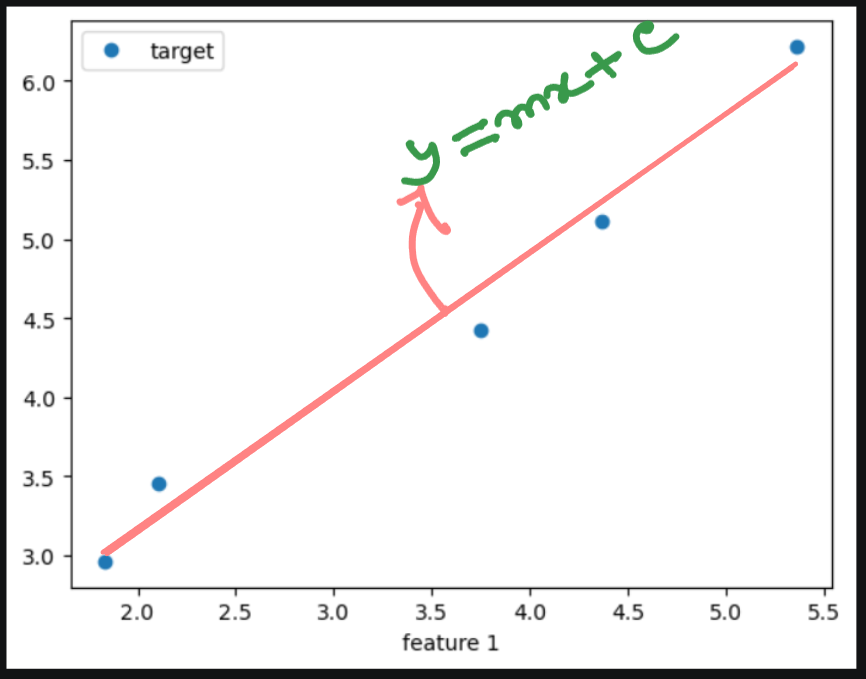



Now, as we are talking 1 feature and 1 target, The feature is is the `input` and the target is the `output`.

In mathematical terms, the `input` is represented with `x` and the `output` is represented with `y` and the line is represented with `y = mx + c`

But, by that equation what we are actually predicting is the `approximate output` for the `input` we give it, not the `exact output`. 

So, we put a hat on it.

$$
\hat{y} = mx + c \hspace{2cm}(1)
$$

Now, to find the line that best fits the data, we need to find the values of $m$ and $c$ and our work is done.

Easy right?

I could've just finish the article here but today I've decided to torture myself to the point of no return.

## Where is the line?

Now, how do we figure out the values of $m$ and $c$?

Firs of, all we have to figure out what the fundamental truth of the best fit line is.

Suppose, the line was here.

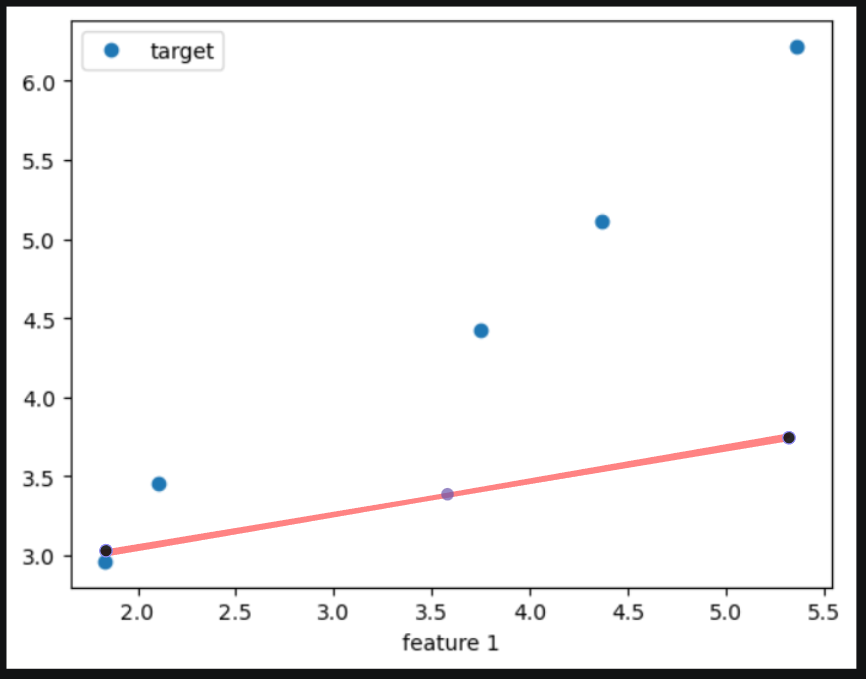

what is the decising factor that tells you whether this is a bad fit?

Distance right? You think how far the line is from the actual values?

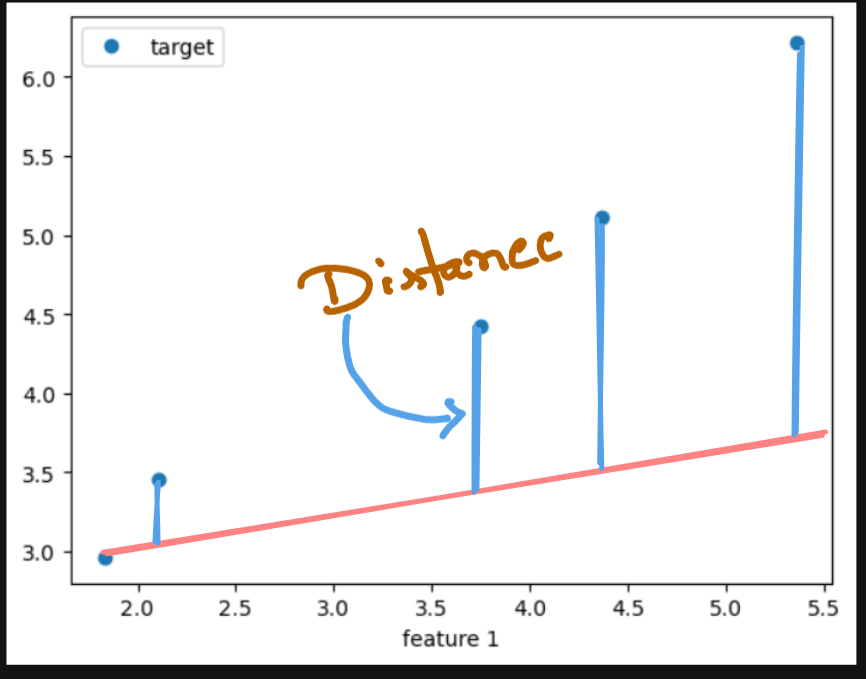

A line is better fit if the distance is less.

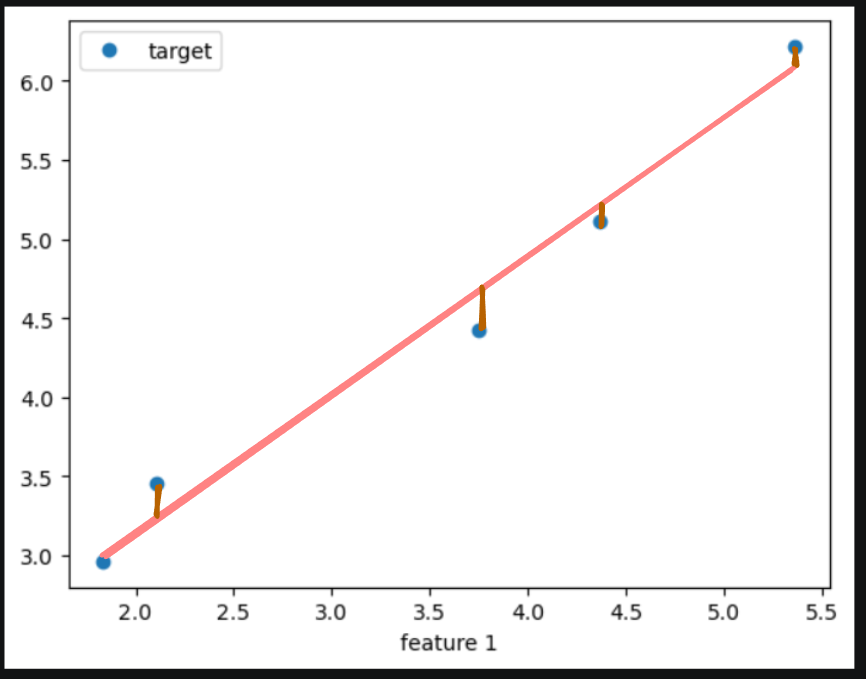

So, have to figure out the distance of the `approximate output` of the line from the `exact output` of the data.

How do we do that?

$$
Distance = y - \hat{y}
$$

The weird thing is if you think hard enough this distance also represents the error `approximation` of the line.

_So, we can say that the line is the best fit if the the sum of the distance of the `approximate output` $\hat{y}$ of the line, from the `exact output` $y$ of the data is minimum._

In simple terms a line is a best fit when the total error is minimum.

> Error is refered to as `residuals` in statistics.

So, the equation to `total error` is:

$$
Error = \sum_{i=1}^{n} (y_i - \hat{y}_i)
$$

In actual math a different version of this equation is used.

$$
RSS = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 \hspace{2cm}(2)
$$




RSS stands for `Residual sum of squares`. Same $error$ equation but squared.

Now you might ask why the squared?

Because for low error values, the total error is low but for high error values, the total error is very high. 

This will help the model to get a better optimization.

$RSS$ is the `key` to all fo our answers. We still need to find the values of $m$ and $c$.

But this is where the mathmatical mumbo jumbo begins.

## Finding the values of $m$ and $c$

We need to find the values of $m$ and $c$.

We use the (1) and replace the $\hat{y}$ with $mx + c$ in equation (2).

We get,

$$
RSS = \sum_{i=1}^{n} (y_i - mx_i - c)^2 \hspace{2cm}(3)
$$


Now, we have a relation between $RSS$ and $m$ and $c$.

We can think of this equation as $RSS = f(m, c)$.

Now, we think.

What does the minimum of $RSS$ tell us?

This is the total squared error of the best fit line. What is the minimum possible total squared error?

ZERO.

Now, think of gradually decreasing the values of $RSS$ with respect to $m$ or $c$.

This will form a curve. And The lowest point of the curve is the `minimum` of $RSS$.

Now, we know that every curve has a slope. So, What should be the slope of the minimum point of the curve?

It's zero.

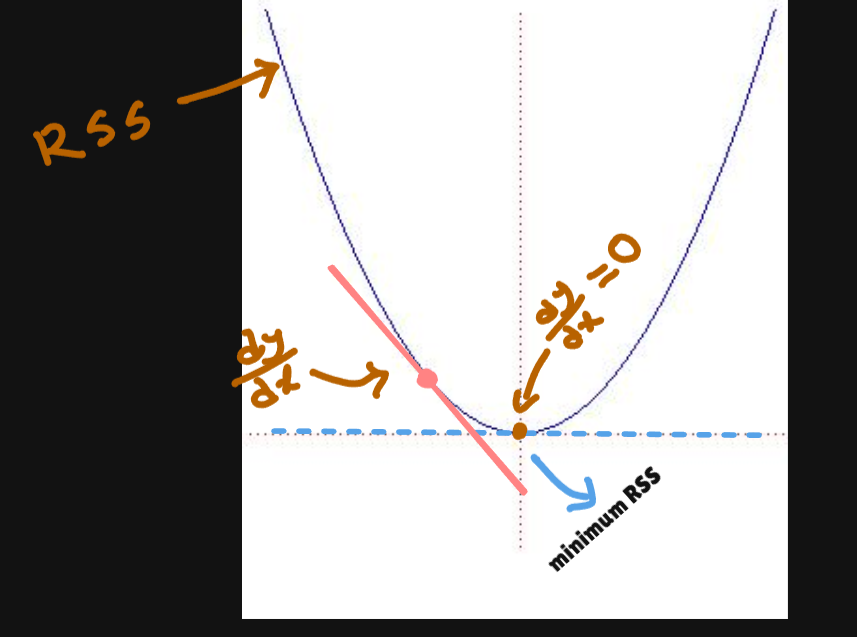

I think this image should clear things up.

Now, when you are talking about slopes of curves, you are talking about the `derivative` of the curve.

And as we know the slope of the minimum point of RSS is zero.

We can say we will find the minimum point of RSS when the derivative of RSS is zero.

The RSS has two variables $m$ and $c$. So, we have to do the partial derivative of RSS with respect to $m$ and $c$.

So, now just do the partial derivative of RSS with respect to $m$ and $c$ and both will be zero at the minimum point of RSS.

$$
\frac{\partial RSS}{\partial m} = 0 \hspace{2cm}(4)
$$

$$
\frac{\partial RSS}{\partial c} = 0 \hspace{2cm}(5)
$$


Start with
$$
RSS=\sum (y_i-mx_i-c)^2
$$

Differentiate with respect to $c$.

$$
\frac{\partial RSS}{\partial c}
=

\sum
2(y_i-mx_i-c)(-1)
$$

which becomes

$$
-2\sum(y_i-mx_i-c)
$$

Set equal to zero.

$$
-2\sum(y_i-mx_i-c)=0
$$

Divide by -2.

$$
\sum(y_i-mx_i-c)=0
$$

If we expand.

$$
\sum y_i
-

m\sum x_i
-
\sum c
=
0
$$

Since there are (n) copies of (c),

$$
\sum c=nc
$$

Therefore

$$
\sum y_i
-
 m\sum x_i
-
 nc
=
0
$$

Solve for (c).

$$
c
=
\frac{\sum y_i-m\sum x_i}{n}
$$

Notice

$$
\bar x=\frac{\sum x_i}{n}
$$

and

$$
\bar y=\frac{\sum y_i}{n}
$$

Therefore

$$
\boxed{c=\bar y-m\bar x}
$$

This is our first important equation.

Now, `Differentiate with respect to m`

Again,

$$
RSS=\sum(y_i-mx_i-c)^2
$$

Differentiate.

Using the chain rule,

$$
\frac{\partial RSS}{\partial m}
=

\sum
2(y_i-mx_i-c)(-x_i)
$$

Simplify.

$$
-2
\sum
x_i(y_i-mx_i-c)
$$

Set equal to zero.

$$
\sum
x_i(y_i-mx_i-c)
=
0
$$

Expand.

$$
\sum x_iy_i
-
m\sum x_i^2
-
 c\sum x_i
=
0
$$

Move terms.

$$
m\sum x_i^2
=

 \sum x_iy_i
-
c\sum x_i
$$

Now substitute

$$
c=\bar y-m\bar x
$$


**Substitute c**

Substitute into the equation.

$$
m\sum x_i^2
=

 \sum x_iy_i
-
(\bar y-m\bar x)\sum x_i
$$

Expand.

$$
m\sum x_i^2
=
\sum x_iy_i
-
\bar y\sum x_i
+
m\bar x\sum x_i
$$

Move every (m) term to one side.

$$
m
\left(
\sum x_i^2
-
\bar x\sum x_i
\right)
=
\sum x_iy_i
-
\bar y\sum x_i
$$

Since

$$
\sum x_i=n\bar x
$$

we obtain

$$
m
\left(
\sum x_i^2
-
n\bar x^2
\right)
=
\sum x_iy_i
-
n\bar x\bar y
$$

Finally,

$$
\boxed{
m=
\frac{\sum x_iy_i-n\bar x\bar y}
{\sum x_i^2-n\bar x^2}
}
$$


**A Cleaner Formula**

Using the identities

$$
\sum(x_i-\bar x)(y_i-\bar y)
=

\sum x_iy_i-n\bar x\bar y
$$

and

$$
\sum(x_i-\bar x)^2
=

\sum x_i^2-n\bar x^2
$$

the slope becomes

$$
\boxed{
m=
\frac{\sum(x_i-\bar x)(y_i-\bar y)}
{\sum(x_i-\bar x)^2}
}
$$

This is the version you'll most often see in statistics and machine learning texts.


**Compute the Intercept**

Now substitute (m) back into

$$
\boxed{
c=\bar y-m\bar x
}
$$

and you're done.


# The Final Equations

The optimal slope is

$$
\boxed{
m=
\frac{\sum(x_i-\bar x)(y_i-\bar y)}
{\sum(x_i-\bar x)^2}
}
$$

The optimal intercept is

$$
\boxed{
c=\bar y-m\bar x
}
$$

The regression line is

$$
\boxed{
\hat y=mx+c
}
$$


And that's it.

We have $m$ and $c$.